# 2026 Strategic Revenue Forecast


Three scenarios on one chart:
1. **Status Quo** — regression acquisition + current promo/repeat/subscription
2. **Lean + Creatine DTC Bundle** (Path 1 — main) — bundle offer at 10% off, higher repeat cohort
3. **Inverted Funnel + 11.11** (Path 2 — backup) — shift promo budget to Day 30–60 + Nov re-engagement flash

**Prerequisites:** `medallion/gold/*.parquet`, `outputs/ds6_roopa_metrics.json`, `outputs/clv_decay_metrics.json`, `configs/forecast_2026_strategic_params.json`

**Packages:** `pandas`, `numpy`, `matplotlib`, `statsmodels`

Run cells top-to-bottom. Edit **Cell 1** (`USER_INPUT`) to impute team assumptions, then re-run.

## Cell 1 — Team assumptions (impute here)

| Parameter | What it is for |
|-----------|----------------|
| `bundle_adoption_share_dtc` | Share of **new DTC customers** taking the Lean+Creatine bundle offer |
| `bundle_discount_pct` | First-order discount on bundle (strategy: 10%) |
| `bundle_aov_multiplier_vs_dtc` | Bundle basket size vs avg DTC first AOV — (Lean price + Creatine price) / DTC AOV |
| `promo_acq_rate_pivot` | Target Day-0 promo acquisition rate after budget shift |
| `acq_volume_penalty_per_promo_pp` | Acq volume loss per **percentage point** cut in promo rate |
| `day30_60_crm_extra_recovery_annual` | Extra repeat SGD/yr from CRM triggers **beyond** Roopa pivot (~4,893) |
| `nov_111_reactivated_customers` | Existing/lapsed customers won back in Nov flash (re-engagement, not acq blitz) |
| `nov_111_flash_order_aov` | Average order value of 11.11 re-engagement orders |

In [1]:
# ---------------------------------------------------------------------------
# USER_INPUT — edit these values, then re-run from this cell downward
# ---------------------------------------------------------------------------
USER_INPUT = {
    # Path 1: Lean + Creatine DTC bundle
    "bundle_adoption_share_dtc": 0.25,
    "bundle_discount_pct": 0.10,
    "bundle_aov_multiplier_vs_dtc": 1.30,

    # Path 2: Inverted funnel
    "promo_acq_rate_pivot": 0.03,
    "acq_volume_penalty_per_promo_pp": 0.015,
    "day30_60_crm_extra_recovery_annual": 0.0,

    # Path 2: 11.11 re-engagement flash (November only)
    "nov_111_reactivated_customers": 120,
    "nov_111_flash_order_aov": 72.0,
}

# Data-backed defaults (from bundling + Roopa DS6 — usually leave as-is)
DATA_DEFAULTS = {
    "bundle_repeat_rate_90d": 0.3649,
    "lean_standalone_repeat_rate_90d": 0.2344,
    "promo_acq_rate_status_quo": 0.0538,
    "annual_recovery_pivot": 4893.26,
}

print("USER_INPUT loaded. Key assumptions:")
for k, v in USER_INPUT.items():
    print(f"  {k}: {v}")

USER_INPUT loaded. Key assumptions:
  bundle_adoption_share_dtc: 0.25
  bundle_discount_pct: 0.1
  bundle_aov_multiplier_vs_dtc: 1.3
  promo_acq_rate_pivot: 0.03
  acq_volume_penalty_per_promo_pp: 0.015
  day30_60_crm_extra_recovery_annual: 0.0
  nov_111_reactivated_customers: 120
  nov_111_flash_order_aov: 72.0


## Cell 2 — Setup & run forecast

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

BASE = Path(".").resolve()
OUTPUT_DIR = BASE / "outputs"
sys.path.insert(0, str(BASE / "scripts"))

from build_strategic_forecast_2026 import (
    build_strategic_forecasts,
    load_strategic_params,
    plot_strategic_scenarios,
    OUTPUT_DIR as OUT,
)

print("Project root:", BASE)
print("Config:", BASE / "configs" / "forecast_2026_strategic_params.json")

Project root: D:\Big Uni Files\Customer_Insights\Applied-Data-Group-Project
Config: D:\Big Uni Files\Customer_Insights\Applied-Data-Group-Project\configs\forecast_2026_strategic_params.json


In [3]:
all_scenarios, meta, actual_revenue = build_strategic_forecasts(
    user_input_override=USER_INPUT,
    write_outputs=True,
)

totals = all_scenarios.groupby("scenario")["total_revenue"].sum().sort_values(ascending=False)
sq = totals.get("Status Quo", totals.min())

print("\n=== 2026 Strategic Scenario Totals ===")
for name, total in totals.items():
    delta = "" if name == "Status Quo" else f"  (+SGD {total - sq:,.0f} vs Status Quo)"
    print(f"  {name}: SGD {total:,.0f}{delta}")

print(f"\nPivot acq volume multiplier: {meta['acq_volume_multiplier_pivot']:.3f}")
print(f"DTC first AOV (from data): SGD {meta['params']['first_aov']['DTC']:.2f}")


=== 2026 Strategic Scenario Totals ===
  Lean + Creatine DTC Bundle: SGD 658,286  (+SGD 13,676 vs Status Quo)
  Inverted Funnel + 11.11: SGD 645,342  (+SGD 731 vs Status Quo)
  Status Quo: SGD 644,610

Pivot acq volume multiplier: 0.964
DTC first AOV (from data): SGD 103.09


## Cell 3 — Monthly breakdown table

In [4]:
breakdown = all_scenarios.groupby("scenario").agg(
    total_revenue=("total_revenue", "sum"),
    new_acq_revenue=("new_acq_revenue", "sum"),
    repeat_revenue=("repeat_revenue", "sum"),
    subscription_revenue=("subscription_revenue", "sum"),
    flash_revenue=("flash_revenue", "sum"),
).round(0)

breakdown["vs_status_quo"] = breakdown["total_revenue"] - breakdown.loc["Status Quo", "total_revenue"]
display(breakdown)

,total_revenue,new_acq_revenue,repeat_revenue,subscription_revenue,flash_revenue,vs_status_quo
scenario,,,,,,
Inverted Funnel + 11.11,645342.0,304543.0,51360.0,280799.0,8640.0,732.0
Lean + Creatine DTC Bundle,658286.0,322933.0,54555.0,280799.0,0.0,13676.0
Status Quo,644610.0,315822.0,47989.0,280799.0,0.0,0.0


## Cell 4 — Scenario chart (main slide)

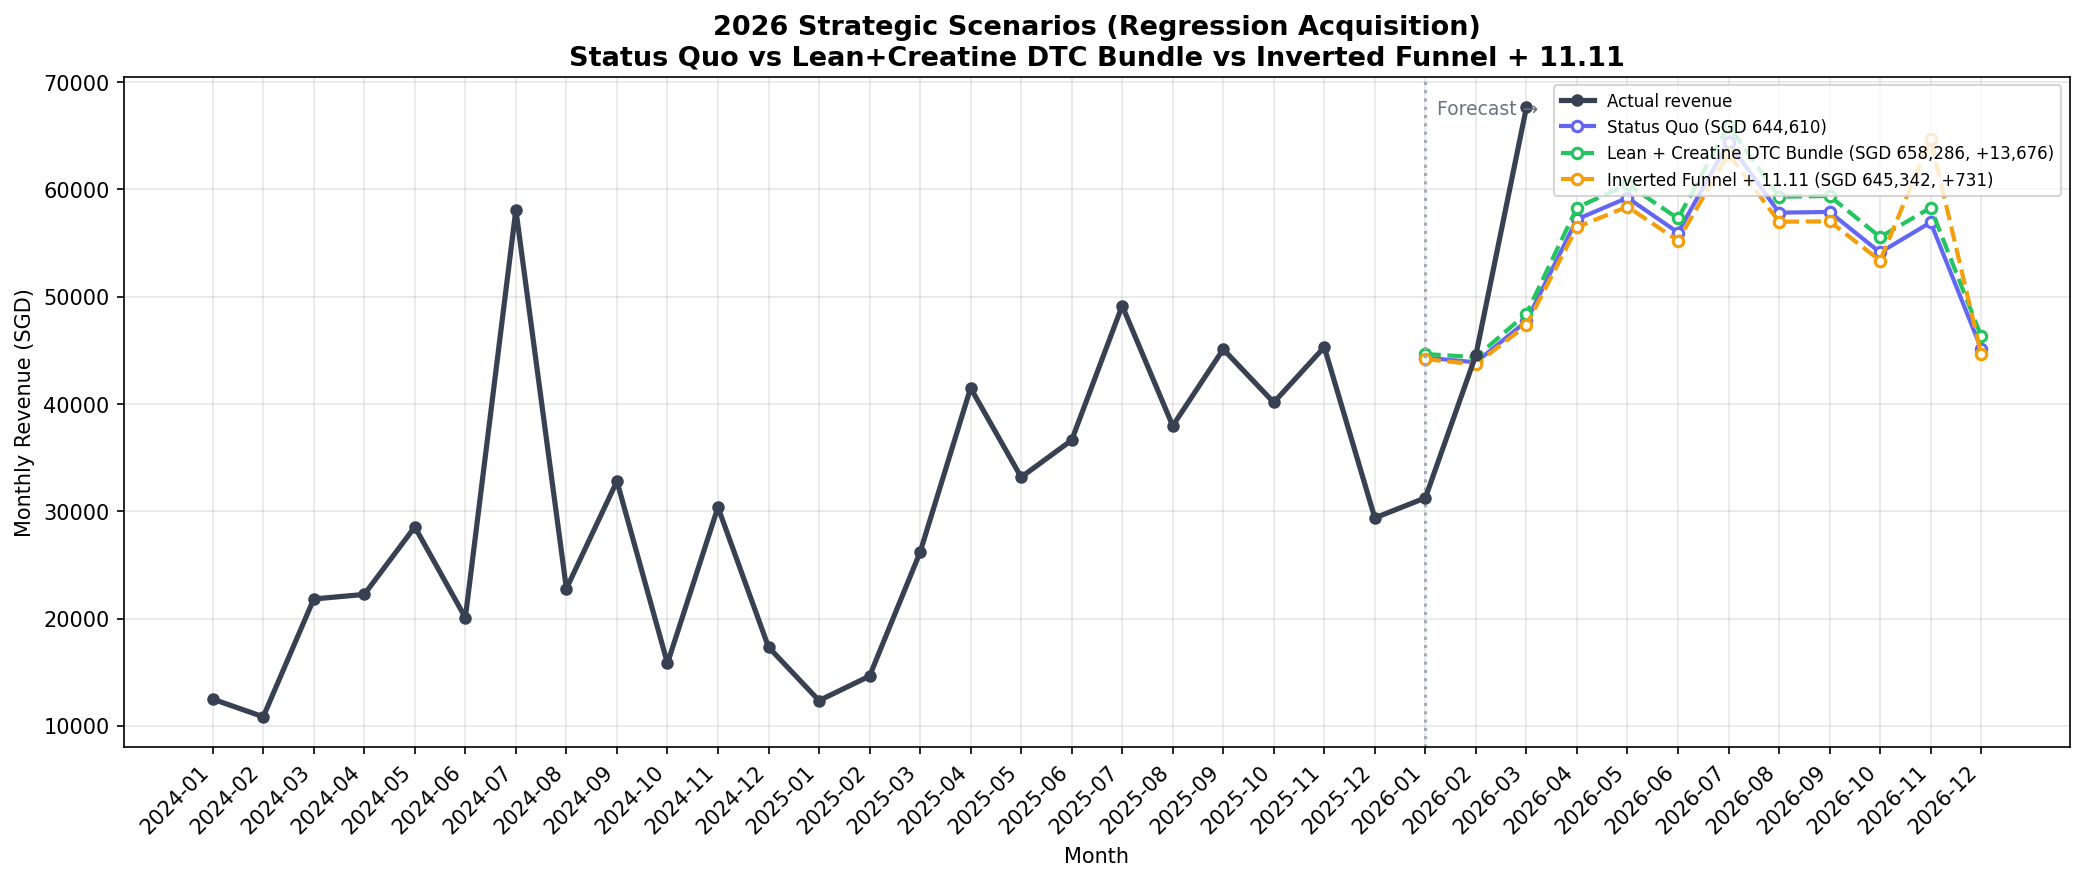

Saved: D:\Big Uni Files\Customer_Insights\Applied-Data-Group-Project\outputs\forecast_2026_strategic_scenarios.png
CSV:   D:\Big Uni Files\Customer_Insights\Applied-Data-Group-Project\outputs\forecast_2026_strategic_monthly.csv
Summary: D:\Big Uni Files\Customer_Insights\Applied-Data-Group-Project\outputs\forecast_2026_strategic_summary.md


In [5]:
chart_path = OUTPUT_DIR / "forecast_2026_strategic_scenarios.png"
if chart_path.exists():
    display(Image(filename=str(chart_path)))
else:
    plot_strategic_scenarios(all_scenarios, chart_path, actual_revenue=actual_revenue)
    display(Image(filename=str(chart_path)))

print(f"Saved: {chart_path}")
print(f"CSV:   {OUTPUT_DIR / 'forecast_2026_strategic_monthly.csv'}")
print(f"Summary: {OUTPUT_DIR / 'forecast_2026_strategic_summary.md'}")

## Cell 5 — Slide bullets

In [6]:
sq_total = totals["Status Quo"]
bundle_name = "Lean + Creatine DTC Bundle"
pivot_name = "Inverted Funnel + 11.11"

print("=== Slide bullets ===")
print(f"• Status Quo 2026: SGD {sq_total:,.0f} (regression acquisition)")
if bundle_name in totals.index:
    b = totals[bundle_name]
    print(f"• Path 1 — Lean+Creatine DTC bundle: SGD {b:,.0f} (+SGD {b - sq_total:,.0f})")
    print(f"  — {USER_INPUT['bundle_adoption_share_dtc']:.0%} of DTC acq on bundle, "
          f"{USER_INPUT['bundle_discount_pct']:.0%} off, repeat lift to {DATA_DEFAULTS['bundle_repeat_rate_90d']:.1%}")
if pivot_name in totals.index:
    p = totals[pivot_name]
    print(f"• Path 2 — Inverted funnel + 11.11: SGD {p:,.0f} (+SGD {p - sq_total:,.0f})")
    print(f"  — Day-0 promo cut to {USER_INPUT['promo_acq_rate_pivot']:.1%}, "
          f"Roopa pivot +SGD {DATA_DEFAULTS['annual_recovery_pivot']:,.0f}/yr, "
          f"Nov flash {int(USER_INPUT['nov_111_reactivated_customers'])} customers")

=== Slide bullets ===
• Status Quo 2026: SGD 644,610 (regression acquisition)
• Path 1 — Lean+Creatine DTC bundle: SGD 658,286 (+SGD 13,676)
  — 25% of DTC acq on bundle, 10% off, repeat lift to 36.5%
• Path 2 — Inverted funnel + 11.11: SGD 645,342 (+SGD 731)
  — Day-0 promo cut to 3.0%, Roopa pivot +SGD 4,893/yr, Nov flash 120 customers
